In [1]:
import numpy as np
import torch
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Probability distribution shift visualization

Visualize the shift in probability distributions between original and shifted data after compiling on the target hardware platform.

We parse the output of Deeploy simulation with a regex pattern to extract expected, actual, and difference values. Then, we compute the distribution via Softmax and visualize the results using seaborn.

In the end, what we are interested in is to see how much the distribution has shifted after quantization and deployment on the target hardware. If we only care about acc@1 then we can ignore small shifts in the distribution, but if we care about acc@5 or acc@10 then even small shifts can have a significant impact on the final accuracy.

In [2]:
def get_prob_distr(data: np.array) -> np.array:
    return torch.softmax(torch.tensor(data), dim=0).numpy()

In [3]:
log = """
Expected:  -0.129770  Actual:  -0.041626  Diff:  -0.088144 at Index            0 in Output 0
Expected:  -0.521375  Actual:   0.463814  Diff:  -0.985189 at Index            1 in Output 0
Expected:   0.471294  Actual:  -0.093363  Diff:   0.564657 at Index            2 in Output 0
Expected:  -0.103438  Actual:  -0.357333  Diff:   0.253895 at Index            3 in Output 0
Expected:  -0.064845  Actual:  -0.354798  Diff:   0.289953 at Index            4 in Output 0
Expected:  -0.793100  Actual:   0.382048  Diff:  -1.175148 at Index            5 in Output 0
Expected:  -1.421052  Actual:   0.399122  Diff:  -1.820173 at Index            6 in Output 0
"""

In [4]:
# ignore the "at Index ..." part
pattern = re.compile(
    r"Expected:\s*([+-]?\d*\.\d+)\s+Actual:\s*([+-]?\d*\.\d+)\s",
    re.MULTILINE,
)
matches = pattern.findall(log)

In [5]:
expected = [float(m[0]) for m in matches]
actual   = [float(m[1]) for m in matches]

In [6]:
original_data = np.array(expected)
shifted_data = np.array(actual)

In [7]:
original_distr = get_prob_distr(original_data)
shifted_distr = get_prob_distr(shifted_data)

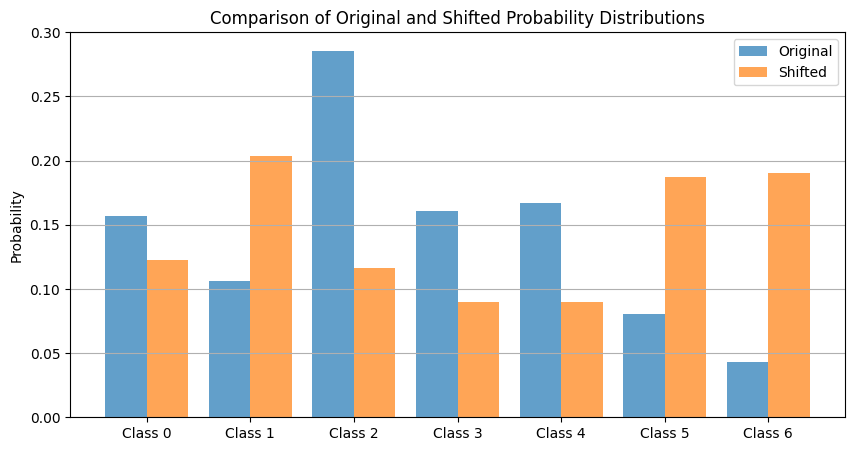

In [8]:
# plot the two distributions (classes of gesture classifier)
plt.figure(figsize=(10, 5))
plt.bar(np.arange(len(original_distr))-0.2, original_distr, width=0.4, label='Original', alpha=0.7)
plt.bar(np.arange(len(shifted_distr))+0.2, shifted_distr, width=0.4, label='Shifted', alpha=0.7)
plt.xticks(np.arange(len(original_distr)), [f'Class {i}' for i in range(len(original_distr))])
plt.ylabel('Probability')
plt.title('Comparison of Original and Shifted Probability Distributions')
plt.legend()
plt.grid(axis='y')
plt.show()

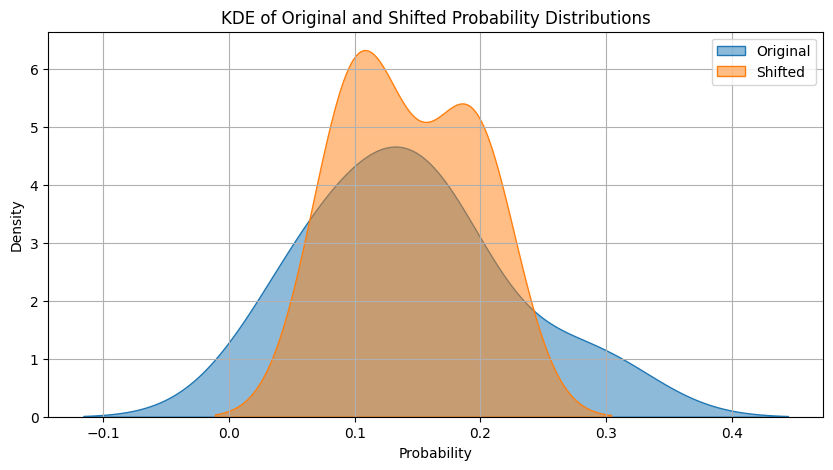

In [10]:
# KDE plot of the two distributions
plt.figure(figsize=(10, 5))
sns.kdeplot(original_distr, label='Original', fill=True, alpha=0.5)
sns.kdeplot(shifted_distr, label='Shifted', fill=True, alpha=0.5)
plt.xlabel('Probability')
plt.ylabel('Density')
plt.title('KDE of Original and Shifted Probability Distributions')
plt.legend()
plt.grid()
plt.show()

In [11]:
# acc@1
print(f"argmax original: {np.argmax(original_distr)}, prob: {np.max(original_distr)}")
print(f"argmax shifted:  {np.argmax(shifted_distr)}, prob: {np.max(shifted_distr)}")

argmax original: 2, prob: 0.2857305505214151
argmax shifted:  1, prob: 0.2034224687165062
